### Reading the data

In [46]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
os.chdir('/Users/Apc/graphical-sampling/simulations')

In [48]:
import os
import pandas as pd
import numpy as np
from package_sampling.utils import inclusion_probabilities

# Assuming inclusion_probabilities is defined elsewhere or imported
# from your package
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv", "aggregated_1000.csv", "regular_1000.csv",
         "AggregatedPop1000.csv", "RegularPop1000.csv"]

def popus(n, path="populations/real"):
    dfs = {} # Better to define inside to keep it clean
    for f in files:
        full_path = os.path.join(path, f)
        if not os.path.exists(full_path):
            print(f"Warning: {full_path} not found.")
            continue
            
        df = pd.read_csv(full_path)
        N_pop = len(df)
        name = f.replace('.csv', '')
        
        # Equal Probabilities (Standard for all)
        pik_ep = np.repeat(n / N_pop, N_pop)
        
        if f in ["aggregated.csv", "regular.csv",  "aggregated_1000.csv", "regular_1000.csv",
                  "AggregatedPop1000.csv", "RegularPop1000.csv"]:
            coords = df.to_numpy()
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'z'      : np.ones(N_pop) # Placeholder if z is missing
            })

        elif f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            # Unequal Probabilities (UP)
            pik_up = inclusion_probabilities(df['copper'].to_numpy().copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['cadmium']
            })

        elif f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5, 100)
            pik_up = inclusion_probabilities(AREA.copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['AREA_A'],
                'y'       :df['AREA']   
            })
            
    return dfs

In [49]:
popu = 'df_swiss'
ep_or_up = 'pik_ep'
n = 20
df = popus(n)[popu]
N = len(df)

# --- Data Preparation ---
target_df = df
coords_data = target_df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()
print(np.corrcoef(df['z'],df['y'])[0,1])
y = df['y']
x = df['z']

0.7863246746742608


In [50]:
import pickle
from pathlib import Path
import numpy as np

# =========================================================
# USER INPUT
# =========================================================

# Main study variable


# Path to saved designs
root = Path("best_designs/swiss")

# =========================================================
# LOAD ALL 12 DESIGNS
# =========================================================

designs = {}

for n in [50, 100, 150]:
    for mode in ["ep", "up"]:

        # Initial GFS
        fname_init = f"initial_design_df_swiss_{n}_pik_{mode}.pkl"

        # Optimized BGFS
        fname_best = f"best_design_df_swiss_{n}_pik_{mode}.pkl"

        with open(root / fname_init, "rb") as f:
            designs[f"initial_{n}_{mode}"] = pickle.load(f)

        with open(root / fname_best, "rb") as f:
            designs[f"best_{n}_{mode}"] = pickle.load(f)

# =========================================================
# COMPUTE EXACT VARIANCES
# =========================================================

results = {}

for key, design in designs.items():

    # -----------------------------
    # Variance for y
    # -----------------------------

    design._nht_variance = None
    design.pop._variable = np.asarray(y, dtype=float)

    var_y = design.nht_variance

    # -----------------------------
    # Variance for x
    # -----------------------------

    design._nht_variance = None
    design.pop._variable = np.asarray(x, dtype=float)

    var_x = design.nht_variance

    # -----------------------------
    # Save
    # -----------------------------

    results[key] = {
        "variance_y": var_y,
        "variance_x": var_x
    }

# =========================================================
# PRINT RESULTS
# =========================================================

for key, vals in results.items():

    print(
        f"{key:25s} | "
        f"Var(y) = {vals['variance_y']:.2f} | "
        f"Var(x) = {vals['variance_x']:.2f}"
    )

# =========================================================
# OPTIONAL: ACCESS EXAMPLES
# =========================================================

# results["initial_50_ep"]["variance_y"]
# results["best_150_up"]["variance_x"]

initial_50_ep             | Var(y) = 91613148.79 | Var(x) = 25658602.34
best_50_ep                | Var(y) = 104294765.13 | Var(x) = 25543351.03
initial_50_up             | Var(y) = 10936268.32 | Var(x) = 1482939.03
best_50_up                | Var(y) = 9451640.06 | Var(x) = 1276008.51
initial_100_ep            | Var(y) = 25684012.95 | Var(x) = 4552963.31
best_100_ep               | Var(y) = 18532711.42 | Var(x) = 3523560.00
initial_100_up            | Var(y) = 747776.41 | Var(x) = 420919.06
best_100_up               | Var(y) = 1170558.86 | Var(x) = 353771.54
initial_150_ep            | Var(y) = 19412717.19 | Var(x) = 2618156.49
best_150_ep               | Var(y) = 16657555.38 | Var(x) = 3698135.31
initial_150_up            | Var(y) = 985243.11 | Var(x) = 356792.43
best_150_up               | Var(y) = 1093852.65 | Var(x) = 424997.86


In [55]:
# =========================================================
# COMPUTE EXACT LOG-SCALE VARIANCES
# =========================================================

results_log = {}

# ---------------------------------------------------------
# Log-transformed variables
# ---------------------------------------------------------

xlog = np.log1p(np.asarray(x, dtype=float))
ylog = np.log1p(np.asarray(y, dtype=float))

for key, design in designs.items():

    # -----------------------------------------------------
    # Variance of log(Y+1)
    # -----------------------------------------------------

    design._nht_variance = None

    design.pop._variable = ylog

    var_log_y = design.nht_variance

    # -----------------------------------------------------
    # Variance of log(X+1)
    # -----------------------------------------------------

    design._nht_variance = None

    design.pop._variable = xlog

    var_log_x = design.nht_variance

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    results_log[key] = {

        "VarLogY": var_log_y,

        "VarLogX": var_log_x
    }

# =========================================================
# PRINT
# =========================================================

for key, vals in results_log.items():

    print(
        f"{key:25s} | "
        f"VarLogY = {vals['VarLogY']:.2f} | "
        f"VarLogX = {vals['VarLogX']:.2f}"
    )

initial_50_ep             | VarLogY = 27179.43 | VarLogX = 26839.70
best_50_ep                | VarLogY = 43352.46 | VarLogX = 39817.18
initial_50_up             | VarLogY = 35885.17 | VarLogX = 27745.87
best_50_up                | VarLogY = 33545.07 | VarLogX = 21682.35
initial_100_ep            | VarLogY = 16044.45 | VarLogX = 9051.89
best_100_ep               | VarLogY = 8704.26 | VarLogX = 3825.52
initial_100_up            | VarLogY = 13211.03 | VarLogX = 8534.31
best_100_up               | VarLogY = 10494.41 | VarLogX = 10199.14
initial_150_ep            | VarLogY = 7023.54 | VarLogX = 6241.73
best_150_ep               | VarLogY = 10107.20 | VarLogX = 7396.65
initial_150_up            | VarLogY = 4839.61 | VarLogX = 4115.87
best_150_up               | VarLogY = 6430.92 | VarLogX = 4831.29


In [63]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# =========================================================
# ASSUMED AVAILABLE
# =========================================================
#
# designs
# results
# coords_data
# y
#
# results[key]["variance_y"]
#
# =========================================================

y = np.asarray(y, dtype=float)

# =========================================================
# LOCAL SPATIAL-BALANCE VARIANCE ESTIMATOR
# =========================================================

def variance_SB(
    sample_idx,
    y,
    coords,
    pik,
    n_neighbors=5
):

    # -----------------------------------------------------
    # Sample data
    # -----------------------------------------------------

    s_coords = coords[sample_idx]

    s_y = y[sample_idx]

    s_pik = pik[sample_idx]

    ns = len(sample_idx)

    # -----------------------------------------------------
    # Distance matrix
    # -----------------------------------------------------

    D = cdist(s_coords, s_coords)

    np.fill_diagonal(D, np.inf)

    # -----------------------------------------------------
    # Neighbour ordering
    # -----------------------------------------------------

    order = np.argsort(D, axis=1)

    # neighbourhood size
    m = min(n_neighbors, ns - 1)

    total = 0.0

    # -----------------------------------------------------
    # Formula implementation
    # -----------------------------------------------------

    for k in range(ns):

        # -------------------------------------------------
        # Include k itself in neighbourhood
        # -------------------------------------------------

        neigh_idx = np.concatenate(
            ([k], order[k, :m])
        )

        nk = len(neigh_idx)

        # -------------------------------------------------
        # Local HT mean
        # -------------------------------------------------

        local_mean = np.sum(

            s_y[neigh_idx]
            /
            s_pik[neigh_idx]

        ) / nk

        # -------------------------------------------------
        # Main variance term
        # -------------------------------------------------

        term = (

            s_y[k] / s_pik[k]
            -
            local_mean

        )**2

        total += (nk / (nk - 1)) * term

    return total

# =========================================================
# EXPECTED VARIANCE ESTIMATOR
# =========================================================

summary_rows = []

for key, design in designs.items():

    # -----------------------------------------------------
    # True variance
    # -----------------------------------------------------

    varY = results[key]["variance_y"]

    # -----------------------------------------------------
    # Inclusion probabilities
    # -----------------------------------------------------

    pik = np.asarray(
        design.pop.inclusions,
        dtype=float
    )

    # -----------------------------------------------------
    # Samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    estimates = []

    # -----------------------------------------------------
    # Loop over all feasible samples
    # -----------------------------------------------------

    for s in samples:

        var_hat_s = variance_SB(

            sample_idx=s,

            y=y,

            coords=coords_data,

            pik=pik,

            n_neighbors=5
        )

        estimates.append(var_hat_s)

    estimates = np.asarray(estimates)

    # -----------------------------------------------------
    # Expected value
    # -----------------------------------------------------

    E_varhat = np.sum(probs * estimates)

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    rel_bias = (varY - E_varhat) / varY

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    summary_rows.append({

        "Design": key,

        "VarY": varY,

        "E_varhat": E_varhat,

        "RelBias": rel_bias
    })

# =========================================================
# OUTPUT TABLE
# =========================================================

df_summary = pd.DataFrame(summary_rows)

tmp = df_summary["Design"].str.split("_", expand=True)

df_summary["Method"] = tmp[0]

df_summary["n"] = tmp[1].astype(int)

if tmp.shape[1] == 4:

    df_summary["pik"] = tmp[2] + "_" + tmp[3]

else:

    df_summary["pik"] = tmp[2]

# =========================================================
# REORDER
# =========================================================

df_summary = df_summary[
    [
        "Method",
        "n",
        "pik",
        "VarY",
        "E_varhat",
        "RelBias"
    ]
]

# =========================================================
# SORT
# =========================================================

df_summary = df_summary.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# =========================================================
# DISPLAY
# =========================================================

pd.set_option(
    "display.float_format",
    "{:,.6f}".format
)

print("\n================================================")
print("EXPECTED LOCAL SB VARIANCE ESTIMATOR")
print("================================================\n")

print(df_summary.to_string(index=False))


EXPECTED LOCAL SB VARIANCE ESTIMATOR

 Method   n pik               VarY          E_varhat   RelBias
   best  50  ep 104,294,765.125739 77,280,794.188897  0.259016
   best 100  ep  18,532,711.420243 40,844,557.882138 -1.203917
   best 150  ep  16,657,555.381700 25,931,228.499480 -0.556725
   best  50  up   9,451,640.064693  9,126,428.758622  0.034408
   best 100  up   1,170,558.855712  4,893,614.698636 -3.180580
   best 150  up   1,093,852.647942  3,349,001.074978 -2.061657
initial  50  ep  91,613,148.793727 78,159,878.846443  0.146849
initial 100  ep  25,684,012.951556 41,226,433.714298 -0.605140
initial 150  ep  19,412,717.186323 26,610,869.503389 -0.370796
initial  50  up  10,936,268.323695  9,175,315.858131  0.161020
initial 100  up     747,776.412206  4,862,796.052387 -5.503008
initial 150  up     985,243.111107  3,346,423.961082 -2.396546


In [56]:
import numpy as np
import pandas as pd

# =========================================================
# ASSUMED AVAILABLE
# =========================================================
#
# designs
# coords_data
#
# results_log must contain:
#
# results_log[key]["VarLogY"]
# results_log[key]["VarLogX"]
#
# =========================================================

# =========================================================
# LOG-TRANSFORMED VARIABLES
# =========================================================

xlog = np.log1p(np.asarray(x, dtype=float))
ylog = np.log1p(np.asarray(y, dtype=float))

# =========================================================
# GLOBAL LOG-LOG REGRESSION
# =========================================================

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

corr = np.corrcoef(xlog, ylog)[0,1]

print("\n================================================")
print("GLOBAL LOG-LOG MODEL")
print("================================================")

print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")
print(f"corr  = {corr:.6f}")
print(f"R^2   = {corr**2:.6f}")

# =========================================================
# POPULATION RESIDUALS
# =========================================================

residuals_pop = ylog - (alpha + beta*xlog)

print("\nResidual summary\n")

print(f"Residual mean = {residuals_pop.mean():.6f}")
print(f"Residual std  = {residuals_pop.std():.6f}")

# =========================================================
# EXACT VARIANCE DECOMPOSITION
# =========================================================

summary_rows = []

for key, design in designs.items():

    # -----------------------------------------------------
    # Exact variance of log(Y+1)
    # -----------------------------------------------------

    varY = results_log[key]["VarLogY"]

    # -----------------------------------------------------
    # Exact variance of log(X+1)
    # -----------------------------------------------------

    varX = results_log[key]["VarLogX"]

    # -----------------------------------------------------
    # Exact variance of residual process
    # -----------------------------------------------------

    design._nht_variance = None

    design.pop._variable = residuals_pop

    varE = design.nht_variance

    # -----------------------------------------------------
    # Variance decomposition
    # -----------------------------------------------------

    approx_var = (beta**2) * varX + varE

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    rel_bias = (varY - approx_var) / varY

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    summary_rows.append({

        "Design": key,

        "VarLogY": varY,

        "VarLogX": varX,

        "VarResidual": varE,

        "ApproxVar": approx_var,

        "RelBias": rel_bias
    })

# =========================================================
# TIDY OUTPUT
# =========================================================

df_summary = pd.DataFrame(summary_rows)

tmp = df_summary["Design"].str.split("_", expand=True)

df_summary["Method"] = tmp[0]

df_summary["n"] = tmp[1].astype(int)

if tmp.shape[1] == 4:

    df_summary["pik"] = tmp[2] + "_" + tmp[3]

else:

    df_summary["pik"] = tmp[2]

# =========================================================
# REORDER
# =========================================================

df_summary = df_summary[
    [
        "Method",
        "n",
        "pik",

        "VarLogY",

        "VarLogX",

        "VarResidual",

        "ApproxVar",

        "RelBias"
    ]
]

# =========================================================
# SORT
# =========================================================

df_summary = df_summary.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# =========================================================
# DISPLAY
# =========================================================

pd.set_option(
    "display.float_format",
    "{:,.6f}".format
)

print("\n================================================")
print("EXACT VARIANCE DECOMPOSITION ESTIMATOR")
print("================================================\n")

print(df_summary.to_string(index=False))


GLOBAL LOG-LOG MODEL
alpha = 0.755259
beta  = 0.943098
corr  = 0.823970
R^2   = 0.678927

Residual summary

Residual mean = 0.000000
Residual std  = 0.793271

EXACT VARIANCE DECOMPOSITION ESTIMATOR

 Method   n pik       VarLogY       VarLogX   VarResidual     ApproxVar   RelBias
   best  50  ep 43,352.457813 39,817.176573  8,850.520592 44,265.291633 -0.021056
   best 100  ep  8,704.260945  3,825.518814  4,707.487682  8,110.036144  0.068268
   best 150  ep 10,107.203475  7,396.654616  1,449.486401  8,028.326294  0.205683
   best  50  up 33,545.065425 21,682.345600 14,596.676282 33,881.702774 -0.010035
   best 100  up 10,494.412813 10,199.143319  7,760.047641 16,831.517708 -0.603855
   best 150  up  6,430.920569  4,831.293471  6,921.111256 11,218.230410 -0.744421
initial  50  ep 27,179.427399 26,839.703044  7,959.343076 31,831.501273 -0.171162
initial 100  ep 16,044.445644  9,051.889146  4,728.344815 12,779.407426  0.203500
initial 150  ep  7,023.536818  6,241.730067  1,159.196071  6,7

In [53]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# =========================================================
# ASSUMED AVAILABLE
# =========================================================
#
# designs
# coords_data
#
# IMPORTANT:
# results_log MUST contain:
#
# results_log[key]["VarLogY"]
# results_log[key]["VarLogX"]
#
# =========================================================

# =========================================================
# LOG-TRANSFORMED VARIABLES
# =========================================================

xlog = np.log1p(np.asarray(x, dtype=float))
ylog = np.log1p(np.asarray(y, dtype=float))

# =========================================================
# GLOBAL LOG-LOG REGRESSION
# =========================================================

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

corr = np.corrcoef(xlog, ylog)[0,1]

print("\n================================================")
print("GLOBAL LOG-LOG MODEL")
print("================================================")

print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")
print(f"corr  = {corr:.6f}")
print(f"R^2   = {corr**2:.6f}")

# =========================================================
# POPULATION RESIDUALS
# =========================================================

residuals_pop = ylog - (alpha + beta*xlog)

# =========================================================
# NEAREST-NEIGHBOUR RESIDUAL ESTIMATOR
# =========================================================

def residual_variance_nn(
    sample_idx,
    residuals,
    coords
):

    s_coords = coords[sample_idx]

    s_resid = residuals[sample_idx]

    # -----------------------------------------------------
    # Pairwise distances
    # -----------------------------------------------------

    D = cdist(s_coords, s_coords)

    np.fill_diagonal(D, np.inf)

    # -----------------------------------------------------
    # First nearest neighbour
    # -----------------------------------------------------

    nn_index = np.argmin(D, axis=1)

    # -----------------------------------------------------
    # Local residual differences
    # -----------------------------------------------------

    diffs = (
        s_resid
        -
        s_resid[nn_index]
    )**2

    # -----------------------------------------------------
    # Grafström-type correction
    # -----------------------------------------------------

    return 0.5 * np.sum(diffs)

# =========================================================
# HYBRID VARIANCE ESTIMATOR
# =========================================================

summary_rows = []

for key, design in designs.items():

    # -----------------------------------------------------
    # IMPORTANT:
    # USE LOG-SCALE VARIANCES
    # -----------------------------------------------------

    varY = results_log[key]["VarLogY"]

    varX = results_log[key]["VarLogX"]

    # -----------------------------------------------------
    # Samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    estimates = []

    # -----------------------------------------------------
    # Loop over all samples
    # -----------------------------------------------------

    for s in samples:

        # ---------------------------------------------
        # Explained component
        # ---------------------------------------------

        explained = (beta**2) * varX

        # ---------------------------------------------
        # Residual correction
        # ---------------------------------------------

        residual_part = residual_variance_nn(
            sample_idx=s,
            residuals=residuals_pop,
            coords=coords_data
        )

        # ---------------------------------------------
        # Hybrid estimator
        # ---------------------------------------------

        var_hat_s = explained + residual_part

        estimates.append(var_hat_s)

    estimates = np.asarray(estimates)

    # -----------------------------------------------------
    # Expected estimated variance
    # -----------------------------------------------------

    E_varhat = np.sum(probs * estimates)

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    rel_bias = (varY - E_varhat) / varY

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    summary_rows.append({

        "Design": key,

        "VarLogY": varY,

        "VarLogX": varX,

        "E_varhat": E_varhat,

        "RelBias": rel_bias
    })

# =========================================================
# TIDY OUTPUT
# =========================================================

df_summary = pd.DataFrame(summary_rows)

tmp = df_summary["Design"].str.split("_", expand=True)

df_summary["Method"] = tmp[0]

df_summary["n"] = tmp[1].astype(int)

if tmp.shape[1] == 4:

    df_summary["pik"] = tmp[2] + "_" + tmp[3]

else:

    df_summary["pik"] = tmp[2]

# =========================================================
# REORDER
# =========================================================

df_summary = df_summary[
    [
        "Method",
        "n",
        "pik",
        "VarLogY",
        "VarLogX",
        "E_varhat",
        "RelBias"
    ]
]

# =========================================================
# SORT
# =========================================================

df_summary = df_summary.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# =========================================================
# DISPLAY
# =========================================================

pd.set_option(
    "display.float_format",
    "{:,.6f}".format
)

print("\n================================================")
print("HYBRID LOG-SCALE VARIANCE ESTIMATOR")
print("================================================\n")

print(df_summary.to_string(index=False))


GLOBAL LOG-LOG MODEL
alpha = 0.755259
beta  = 0.943098
corr  = 0.823970
R^2   = 0.678927

HYBRID LOG-SCALE VARIANCE ESTIMATOR

 Method   n pik       VarLogY       VarLogX      E_varhat  RelBias
   best  50  ep 43,352.457813 39,817.176573 35,441.797164 0.182473
   best 100  ep  8,704.260945  3,825.518814  3,453.165707 0.603279
   best 150  ep 10,107.203475  7,396.654616  6,658.027844 0.341259
   best  50  up 33,545.065425 21,682.345600 19,328.752698 0.423797
   best 100  up 10,494.412813 10,199.143319  9,151.381346 0.127976
   best 150  up  6,430.920569  4,831.293471  4,403.227967 0.315304
initial  50  ep 27,179.427399 26,839.703044 23,899.728584 0.120668
initial 100  ep 16,044.445644  9,051.889146  8,100.644435 0.495112
initial 150  ep  7,023.536818  6,241.730067  5,629.458354 0.198487
initial  50  up 35,885.172072 27,745.869720 24,717.690563 0.311200
initial 100  up 13,211.029224  8,534.310725  7,670.276096 0.419404
initial 150  up  4,839.610151  4,115.867163  3,766.737149 0.221686


In [42]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# =========================================================
# USER INPUT
# =========================================================

popu = 'df_swiss'
ep_or_up = 'pik_ep'
n = 20

df = popus(n)[popu]

N = len(df)

# ---------------------------------------------------------
# Coordinates
# ---------------------------------------------------------

coords = df[['coord_x', 'coord_y']].to_numpy()

# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

y = np.asarray(df['y'], dtype=float)
x = np.asarray(df['z'], dtype=float)

print("\nCorrelation(y,x) =")
print(np.corrcoef(x, y)[0,1])

# =========================================================
# LOG-TRANSFORMED MODEL
# =========================================================

xlog = np.log1p(x)
ylog = np.log1p(y)

# ---------------------------------------------------------
# Global regression
# ---------------------------------------------------------

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

print("\n================================================")
print("GLOBAL LOG-LOG MODEL")
print("================================================")

print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

# =========================================================
# POPULATION RESIDUALS
# =========================================================

residuals_pop = ylog - (alpha + beta*xlog)

# =========================================================
# LOAD DESIGN
# =========================================================

root = Path("best_designs/swiss")

fname_init = f"initial_design_df_swiss_{n}_{ep_or_up}.pkl"

fname_best = f"best_design_df_swiss_{n}_{ep_or_up}.pkl"

with open(root / fname_init, "rb") as f:
    design_initial = pickle.load(f)

with open(root / fname_best, "rb") as f:
    design_best = pickle.load(f)

designs = {
    "initial": design_initial,
    "best": design_best
}

# =========================================================
# ADAPTIVE m-NEIGHBOUR RESIDUAL ESTIMATOR
# =========================================================

def adaptive_residual_variance(
    sample_idx,
    residuals,
    coords,
    m
):

    s_coords = coords[sample_idx]

    s_resid = residuals[sample_idx]

    ns = len(sample_idx)

    # -----------------------------------------------------
    # Distance matrix
    # -----------------------------------------------------

    D = cdist(s_coords, s_coords)

    np.fill_diagonal(D, np.inf)

    # -----------------------------------------------------
    # m-th nearest neighbour
    # -----------------------------------------------------

    order = np.argsort(D, axis=1)

    # ensure m valid
    m_eff = min(m, ns - 1)

    nn_index = order[:, m_eff - 1]

    # -----------------------------------------------------
    # Residual differences
    # -----------------------------------------------------

    diffs = (
        s_resid
        -
        s_resid[nn_index]
    )**2

    # -----------------------------------------------------
    # Variance estimator
    # -----------------------------------------------------

    return 0.5 * np.sum(diffs)

# =========================================================
# TEST DIFFERENT m VALUES
# =========================================================

m_values = [1, 2, 3, 5, 7, 10]

summary_rows = []

for method, design in designs.items():

    # -----------------------------------------------------
    # Exact variance of log(Y+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = ylog

    varY = design.nht_variance

    # -----------------------------------------------------
    # Exact variance of log(X+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = xlog

    varX = design.nht_variance

    # -----------------------------------------------------
    # Samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    # -----------------------------------------------------
    # Try different neighbourhood sizes
    # -----------------------------------------------------

    for m in m_values:

        estimates = []

        for s in samples:

            # ---------------------------------------------
            # Explained component
            # ---------------------------------------------

            explained = (beta**2) * varX

            # ---------------------------------------------
            # Residual correction
            # ---------------------------------------------

            residual_part = adaptive_residual_variance(
                sample_idx=s,
                residuals=residuals_pop,
                coords=coords,
                m=m
            )

            # ---------------------------------------------
            # Hybrid estimator
            # ---------------------------------------------

            var_hat_s = explained + residual_part

            estimates.append(var_hat_s)

        estimates = np.asarray(estimates)

        # -------------------------------------------------
        # Expected estimated variance
        # -------------------------------------------------

        E_varhat = np.sum(probs * estimates)

        # -------------------------------------------------
        # Relative bias
        # -------------------------------------------------

        rel_bias = (varY - E_varhat) / varY

        # -------------------------------------------------
        # Save
        # -------------------------------------------------

        summary_rows.append({

            "Method": method,
            "m": m,
            "VarLogY": varY,
            "E_varhat": E_varhat,
            "RelBias": rel_bias
        })

# =========================================================
# RESULTS
# =========================================================

df_summary = pd.DataFrame(summary_rows)

pd.set_option("display.float_format", "{:,.6f}".format)

print("\n================================================")
print("ADAPTIVE m-NEIGHBOUR VARIANCE ESTIMATOR")
print("================================================\n")

print(df_summary.to_string(index=False))

# =========================================================
# BEST m
# =========================================================

best_rows = []

for method in df_summary["Method"].unique():

    tmp = df_summary[df_summary["Method"] == method]

    idx = np.argmin(np.abs(tmp["RelBias"]))

    best_rows.append(tmp.iloc[idx])

df_best = pd.DataFrame(best_rows)

print("\n================================================")
print("BEST m VALUES")
print("================================================\n")

print(df_best.to_string(index=False))


Correlation(y,x) =
0.7863246746742608

GLOBAL LOG-LOG MODEL
alpha = 0.755259
beta  = 0.943098


FileNotFoundError: [Errno 2] No such file or directory: 'best_designs\\swiss\\initial_design_df_swiss_20_pik_ep.pkl'

initial_50_ep             | Var(y) = 91613148.79 | Var(x) = 25658602.34
best_50_ep                | Var(y) = 104294765.13 | Var(x) = 25543351.03
initial_50_up             | Var(y) = 10936268.32 | Var(x) = 1482939.03
best_50_up                | Var(y) = 9451640.06 | Var(x) = 1276008.51
initial_100_ep            | Var(y) = 25684012.95 | Var(x) = 4552963.31
best_100_ep               | Var(y) = 18532711.42 | Var(x) = 3523560.00
initial_100_up            | Var(y) = 747776.41 | Var(x) = 420919.06
best_100_up               | Var(y) = 1170558.86 | Var(x) = 353771.54
initial_150_ep            | Var(y) = 19412717.19 | Var(x) = 2618156.49
best_150_ep               | Var(y) = 16657555.38 | Var(x) = 3698135.31
initial_150_up            | Var(y) = 985243.11 | Var(x) = 356792.43
best_150_up               | Var(y) = 1093852.65 | Var(x) = 424997.86


In [24]:
print(np.std(x), np.std(y))

34.05936474006998 66.17542173878765


In [41]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# =========================================================
# USER INPUT
# =========================================================

popu = 'df_swiss'
ep_or_up = 'pik_ep'
n = 20

df = popus(n)[popu]

N = len(df)

# ---------------------------------------------------------
# Coordinates
# ---------------------------------------------------------

coords = df[['coord_x', 'coord_y']].to_numpy()

# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

y = np.asarray(df['y'], dtype=float)
x = np.asarray(df['z'], dtype=float)

print("\nCorrelation(y,x) =")
print(np.corrcoef(x, y)[0,1])

# =========================================================
# LOG-TRANSFORMED MODEL
# =========================================================

xlog = np.log1p(x)
ylog = np.log1p(y)

# ---------------------------------------------------------
# Global regression
# ---------------------------------------------------------

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

print("\n================================================")
print("GLOBAL LOG-LOG MODEL")
print("================================================")

print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

# =========================================================
# POPULATION RESIDUALS
# =========================================================

residuals_pop = ylog - (alpha + beta*xlog)

# =========================================================
# LOAD DESIGN
# =========================================================

root = Path("best_designs/swiss")

fname_init = f"initial_design_df_swiss_{n}_{ep_or_up}.pkl"

fname_best = f"best_design_df_swiss_{n}_{ep_or_up}.pkl"

with open(root / fname_init, "rb") as f:
    design_initial = pickle.load(f)

with open(root / fname_best, "rb") as f:
    design_best = pickle.load(f)

designs = {
    "initial": design_initial,
    "best": design_best
}

# =========================================================
# ADAPTIVE m-NEIGHBOUR RESIDUAL ESTIMATOR
# =========================================================

def adaptive_residual_variance(
    sample_idx,
    residuals,
    coords,
    m
):

    s_coords = coords[sample_idx]

    s_resid = residuals[sample_idx]

    ns = len(sample_idx)

    # -----------------------------------------------------
    # Distance matrix
    # -----------------------------------------------------

    D = cdist(s_coords, s_coords)

    np.fill_diagonal(D, np.inf)

    # -----------------------------------------------------
    # m-th nearest neighbour
    # -----------------------------------------------------

    order = np.argsort(D, axis=1)

    # ensure m valid
    m_eff = min(m, ns - 1)

    nn_index = order[:, m_eff - 1]

    # -----------------------------------------------------
    # Residual differences
    # -----------------------------------------------------

    diffs = (
        s_resid
        -
        s_resid[nn_index]
    )**2

    # -----------------------------------------------------
    # Variance estimator
    # -----------------------------------------------------

    return 0.5 * np.sum(diffs)

# =========================================================
# TEST DIFFERENT m VALUES
# =========================================================

m_values = [1, 2, 3, 5, 7, 10]

summary_rows = []

for method, design in designs.items():

    # -----------------------------------------------------
    # Exact variance of log(Y+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = ylog

    varY = design.nht_variance

    # -----------------------------------------------------
    # Exact variance of log(X+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = xlog

    varX = design.nht_variance

    # -----------------------------------------------------
    # Samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    # -----------------------------------------------------
    # Try different neighbourhood sizes
    # -----------------------------------------------------

    for m in m_values:

        estimates = []

        for s in samples:

            # ---------------------------------------------
            # Explained component
            # ---------------------------------------------

            explained = (beta**2) * varX

            # ---------------------------------------------
            # Residual correction
            # ---------------------------------------------

            residual_part = adaptive_residual_variance(
                sample_idx=s,
                residuals=residuals_pop,
                coords=coords,
                m=m
            )

            # ---------------------------------------------
            # Hybrid estimator
            # ---------------------------------------------

            var_hat_s = explained + residual_part

            estimates.append(var_hat_s)

        estimates = np.asarray(estimates)

        # -------------------------------------------------
        # Expected estimated variance
        # -------------------------------------------------

        E_varhat = np.sum(probs * estimates)

        # -------------------------------------------------
        # Relative bias
        # -------------------------------------------------

        rel_bias = (varY - E_varhat) / varY

        # -------------------------------------------------
        # Save
        # -------------------------------------------------

        summary_rows.append({

            "Method": method,
            "m": m,
            "VarLogY": varY,
            "E_varhat": E_varhat,
            "RelBias": rel_bias
        })

# =========================================================
# RESULTS
# =========================================================

df_summary = pd.DataFrame(summary_rows)

pd.set_option("display.float_format", "{:,.6f}".format)

print("\n================================================")
print("ADAPTIVE m-NEIGHBOUR VARIANCE ESTIMATOR")
print("================================================\n")

print(df_summary.to_string(index=False))

# =========================================================
# BEST m
# =========================================================

best_rows = []

for method in df_summary["Method"].unique():

    tmp = df_summary[df_summary["Method"] == method]

    idx = np.argmin(np.abs(tmp["RelBias"]))

    best_rows.append(tmp.iloc[idx])

df_best = pd.DataFrame(best_rows)

print("\n================================================")
print("BEST m VALUES")
print("================================================\n")

print(df_best.to_string(index=False))


Correlation(y,x) =
0.7863246746742608

GLOBAL LOG-LOG MODEL
alpha = 0.755259
beta  = 0.943098


FileNotFoundError: [Errno 2] No such file or directory: 'best_designs\\swiss\\initial_design_df_swiss_20_pik_ep.pkl'

In [30]:
# =========================================================
# EXPECTED MODEL-ASSISTED VARIANCE ESTIMATOR
# WITH DEBUGGING
# =========================================================

summary = {}

for key, design in designs.items():

    # -----------------------------------------------------
    # Exact variances already computed
    # -----------------------------------------------------

    varY = results[key]["variance_y"]
    varX = results[key]["variance_x"]

    # -----------------------------------------------------
    # All feasible samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    estimated_variances = []
    betas = []
    correlations = []
    denoms = []

    # -----------------------------------------------------
    # Loop over all samples
    # -----------------------------------------------------

    for s in samples:

        ys = np.asarray(y.iloc[s], dtype=float)
        xs = np.asarray(x.iloc[s], dtype=float)

        # -------------------------------------------------
        # Estimate beta from the sample
        # -------------------------------------------------

        xbar = xs.mean()
        ybar = ys.mean()

        denom = np.sum((xs - xbar)**2)

        denoms.append(denom)

        if denom < 1e-12:

            beta_hat = np.nan
            corr_hat = np.nan
            var_hat_s = np.nan

        else:

            beta_hat = (
                np.sum((xs - xbar)*(ys - ybar))
                / denom
            )

            corr_hat = np.corrcoef(xs, ys)[0, 1]

            # ---------------------------------------------
            # Variance estimator for this sample
            # ---------------------------------------------

            var_hat_s = (beta_hat**2) * varX

        estimated_variances.append(var_hat_s)
        betas.append(beta_hat)
        correlations.append(corr_hat)

    # -----------------------------------------------------
    # Convert arrays
    # -----------------------------------------------------

    estimated_variances = np.asarray(estimated_variances, dtype=float)
    betas = np.asarray(betas, dtype=float)
    correlations = np.asarray(correlations, dtype=float)
    denoms = np.asarray(denoms, dtype=float)

    # -----------------------------------------------------
    # Expected estimated variance
    # -----------------------------------------------------

    E_varhat = np.nansum(probs * estimated_variances)

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    relative_bias = (varY - E_varhat) / varY

    # -----------------------------------------------------
    # Save everything
    # -----------------------------------------------------

    summary[key] = {

        # Main results
        "VarY": varY,
        "VarX": varX,
        "E_varhat": E_varhat,
        "RelativeBias": relative_bias,

        # Debugging
        "BetaMean": np.nanmean(betas),
        "BetaStd": np.nanstd(betas),
        "BetaMin": np.nanmin(betas),
        "BetaMax": np.nanmax(betas),

        "CorrMean": np.nanmean(correlations),
        "CorrStd": np.nanstd(correlations),

        "DenomMin": np.nanmin(denoms),
        "DenomMean": np.nanmean(denoms),
    }

# =========================================================
# TIDY OUTPUT TABLE
# =========================================================

import pandas as pd

rows = []

for key, vals in summary.items():

    rows.append({

        "Design": key,

        "VarY": vals["VarY"],
        "VarX": vals["VarX"],
        "E_varhat": vals["E_varhat"],
        "RelBias": vals["RelativeBias"],

        "BetaMean": vals["BetaMean"],
        "BetaStd": vals["BetaStd"],
        "BetaMin": vals["BetaMin"],
        "BetaMax": vals["BetaMax"],

        "CorrMean": vals["CorrMean"],
        "CorrStd": vals["CorrStd"],

        "DenomMin": vals["DenomMin"],
        "DenomMean": vals["DenomMean"],
    })

df_summary = pd.DataFrame(rows)

# ---------------------------------------------------------
# Split design name
# ---------------------------------------------------------

tmp = df_summary["Design"].str.split("_", expand=True)

df_summary["Method"] = tmp[0]
df_summary["n"] = tmp[1].astype(int)
df_summary["pik"] = tmp[2]

# ---------------------------------------------------------
# Final ordering
# ---------------------------------------------------------

df_summary = df_summary[
    [
        "Method",
        "n",
        "pik",

        "VarY",
        "VarX",
        "E_varhat",
        "RelBias",

        "BetaMean",
        "BetaStd",
        "BetaMin",
        "BetaMax",

        "CorrMean",
        "CorrStd",

        "DenomMin",
        "DenomMean",
    ]
]

# ---------------------------------------------------------
# Sort
# ---------------------------------------------------------

df_summary = df_summary.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# ---------------------------------------------------------
# Pretty display
# ---------------------------------------------------------

pd.set_option("display.float_format", "{:,.4f}".format)

print(df_summary.to_string(index=False))

 Method   n pik             VarY            VarX        E_varhat  RelBias  BetaMean  BetaStd  BetaMin  BetaMax  CorrMean  CorrStd     DenomMin    DenomMean
   best  50  ep 104,294,765.1257 25,543,351.0316 56,374,520.9819   0.4595    1.3851   0.5371   0.8451   3.4322    0.7604   0.1754   2,073.1768  56,613.3089
   best 100  ep  18,532,711.4202  3,523,559.9975  8,895,874.1243   0.5200    1.4851   0.5649   0.9720   3.1914    0.8188   0.1377  10,952.2453 115,620.9041
   best 150  ep  16,657,555.3817  3,698,135.3099  9,129,918.6047   0.4519    1.4622   0.5751   0.9711   2.9944    0.8142   0.0917  55,024.0977 173,402.8829
   best  50  up   9,451,640.0647  1,276,008.5109  2,630,449.7785   0.7217    1.3506   0.4953   0.8239   2.4599    0.7803   0.0805 103,046.5122 255,926.6265
   best 100  up   1,170,558.8557    353,771.5431    791,905.4005   0.3235    1.4410   0.4064   0.9196   1.9842    0.7553   0.0685 346,461.4212 517,841.8380
   best 150  up   1,093,852.6479    424,997.8650    883,995.6439

In [31]:
import numpy as np
import pandas as pd

# =========================================================
# GLOBAL REGRESSION COEFFICIENT
# =========================================================

y_all = np.asarray(df['y'], dtype=float)
x_all = np.asarray(df['z'], dtype=float)

xbar = x_all.mean()
ybar = y_all.mean()

beta = (
    np.sum((x_all - xbar)*(y_all - ybar))
    /
    np.sum((x_all - xbar)**2)
)

corr = np.corrcoef(x_all, y_all)[0,1]

print(f"\nGlobal beta = {beta:.6f}")
print(f"Correlation  = {corr:.6f}")

# =========================================================
# COMPARE beta^2 Var(X) WITH Var(Y)
# =========================================================

rows = []

for key in results:

    varY = results[key]["variance_y"]
    varX = results[key]["variance_x"]

    approx_varY = (beta**2) * varX

    rel_bias = (varY - approx_varY) / varY

    rows.append({
        "Design": key,
        "VarY": varY,
        "beta2_VarX": approx_varY,
        "RelativeBias": rel_bias
    })

df_compare = pd.DataFrame(rows)

# ---------------------------------------------------------
# Split names
# ---------------------------------------------------------

tmp = df_compare["Design"].str.split("_", expand=True)

df_compare["Method"] = tmp[0]
df_compare["n"] = tmp[1].astype(int)
df_compare["pik"] = tmp[2]

# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

df_compare = df_compare[
    [
        "Method",
        "n",
        "pik",
        "VarY",
        "beta2_VarX",
        "RelativeBias"
    ]
]

df_compare = df_compare.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

pd.set_option("display.float_format", "{:,.4f}".format)

print("\n")
print(df_compare.to_string(index=False))


Global beta = 1.527784
Correlation  = 0.786325


 Method   n pik             VarY      beta2_VarX  RelativeBias
   best  50  ep 104,294,765.1257 59,621,380.5823        0.4283
   best 100  ep  18,532,711.4202  8,224,430.3560        0.5562
   best 150  ep  16,657,555.3817  8,631,911.0003        0.4818
   best  50  up   9,451,640.0647  2,978,363.6829        0.6849
   best 100  up   1,170,558.8557    825,747.0910        0.2946
   best 150  up   1,093,852.6479    991,998.2474        0.0931
initial  50  ep  91,613,148.7937 59,890,391.5747        0.3463
initial 100  ep  25,684,012.9516 10,627,186.6163        0.5862
initial 150  ep  19,412,717.1863  6,111,105.1655        0.6852
initial  50  up  10,936,268.3237  3,461,365.4318        0.6835
initial 100  up     747,776.4122    982,477.8102       -0.3139
initial 150  up     985,243.1111    832,798.2296        0.1547


In [36]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# =========================================================
# LOG-TRANSFORMED VARIABLES
# =========================================================

xlog = np.log1p(np.asarray(df['z'], dtype=float))
ylog = np.log1p(np.asarray(df['y'], dtype=float))

# =========================================================
# GLOBAL LOG-LOG REGRESSION
# =========================================================

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

print("\n================================================")
print("GLOBAL LOG-LOG MODEL")
print("================================================")

print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

# =========================================================
# POPULATION RESIDUALS
# =========================================================

residuals_pop = ylog - (alpha + beta*xlog)

# =========================================================
# COORDINATES
# =========================================================

coords = np.asarray(df[['x', 'y']], dtype=float)

# =========================================================
# LOCAL SB VARIANCE ESTIMATOR
# =========================================================

def local_SB_variance(sample_idx, residuals, coords):

    s_coords = coords[sample_idx]
    s_resid  = residuals[sample_idx]

    n = len(sample_idx)

    # -----------------------------------------------------
    # Pairwise distances among sampled units
    # -----------------------------------------------------

    D = cdist(s_coords, s_coords)

    # Ignore self-distance
    np.fill_diagonal(D, np.inf)

    # -----------------------------------------------------
    # Nearest neighbour for each sampled unit
    # -----------------------------------------------------

    nn_index = np.argmin(D, axis=1)

    # -----------------------------------------------------
    # Grafström-Schelin estimator
    # -----------------------------------------------------

    diffs = (
        s_resid
        -
        s_resid[nn_index]
    )**2

    var_sb = 0.5 * np.sum(diffs)

    return var_sb

# =========================================================
# HYBRID VARIANCE ESTIMATOR
# =========================================================

summary = {}

for key, design in designs.items():

    # -----------------------------------------------------
    # Exact variance of log(Y+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = ylog

    varY = design.nht_variance

    # -----------------------------------------------------
    # Exact variance of log(X+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = xlog

    varX = design.nht_variance

    # -----------------------------------------------------
    # Samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    hybrid_estimates = []

    # -----------------------------------------------------
    # Loop over all samples
    # -----------------------------------------------------

    for s in samples:

        # ---------------------------------------------
        # Exact explained component
        # ---------------------------------------------

        explained = (beta**2) * varX

        # ---------------------------------------------
        # Local residual variance
        # ---------------------------------------------

        residual_part = local_SB_variance(
            sample_idx=s,
            residuals=residuals_pop,
            coords=coords
        )

        # ---------------------------------------------
        # Hybrid estimator
        # ---------------------------------------------

        var_hat_s = explained + residual_part

        hybrid_estimates.append(var_hat_s)

    hybrid_estimates = np.asarray(hybrid_estimates)

    # -----------------------------------------------------
    # Expected estimated variance
    # -----------------------------------------------------

    E_varhat = np.sum(probs * hybrid_estimates)

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    rel_bias = (varY - E_varhat) / varY

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    summary[key] = {

        "VarLogY": varY,
        "VarLogX": varX,
        "E_varhat": E_varhat,
        "RelativeBias": rel_bias
    }

# =========================================================
# TIDY OUTPUT TABLE
# =========================================================

rows = []

for key, vals in summary.items():

    rows.append({

        "Design": key,
        "VarLogY": vals["VarLogY"],
        "E_varhat": vals["E_varhat"],
        "RelBias": vals["RelativeBias"]
    })

df_summary = pd.DataFrame(rows)

# =========================================================
# SPLIT DESIGN NAMES
# =========================================================

tmp = df_summary["Design"].str.split("_", expand=True)

df_summary["Method"] = tmp[0]
df_summary["n"] = tmp[1].astype(int)
df_summary["pik"] = tmp[2]

# =========================================================
# REORDER
# =========================================================

df_summary = df_summary[
    [
        "Method",
        "n",
        "pik",
        "VarLogY",
        "E_varhat",
        "RelBias"
    ]
]

# =========================================================
# SORT
# =========================================================

df_summary = df_summary.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# =========================================================
# DISPLAY
# =========================================================

pd.set_option("display.float_format", "{:,.6f}".format)

print("\n================================================")
print("HYBRID VARIANCE ESTIMATOR")
print("================================================\n")

print(df_summary.to_string(index=False))


GLOBAL LOG-LOG MODEL
alpha = 0.755259
beta  = 0.943098


KeyError: "['x'] not in index"

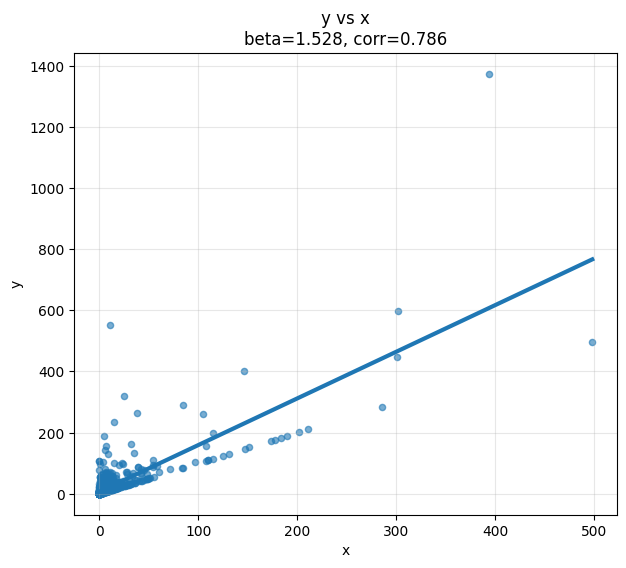


Residual summary:

Residual mean : 0.000000
Residual std  : 40.884068

R^2 = 0.6183


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# DATA
# =========================================================

x_all = np.asarray(df['z'], dtype=float)
y_all = np.asarray(df['y'], dtype=float)

# =========================================================
# GLOBAL REGRESSION
# =========================================================

xbar = x_all.mean()
ybar = y_all.mean()

beta = (
    np.sum((x_all - xbar)*(y_all - ybar))
    /
    np.sum((x_all - xbar)**2)
)

alpha = ybar - beta*xbar

# =========================================================
# PREDICTIONS AND RESIDUALS
# =========================================================

yhat = alpha + beta*x_all
residuals = y_all - yhat

corr = np.corrcoef(x_all, y_all)[0,1]

# =========================================================
# SCATTER PLOT
# =========================================================

plt.figure(figsize=(7,6))

plt.scatter(
    x_all,
    y_all,
    alpha=0.6,
    s=20
)

# regression line
xx = np.linspace(x_all.min(), x_all.max(), 200)
yy = alpha + beta*xx

plt.plot(xx, yy, linewidth=3)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    f"y vs x\n"
    f"beta={beta:.3f}, corr={corr:.3f}"
)

plt.grid(alpha=0.3)

plt.show()

# =========================================================
# RESIDUAL DIAGNOSTIC
# =========================================================

print("\nResidual summary:\n")

print(f"Residual mean : {residuals.mean():.6f}")
print(f"Residual std  : {residuals.std():.6f}")

print(f"\nR^2 = {corr**2:.4f}")

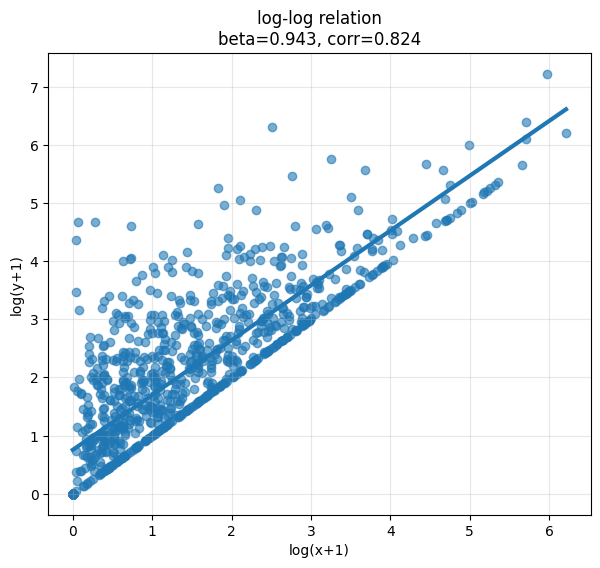


R^2 = 0.6789


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# LOG TRANSFORM
# =========================================================

xlog = np.log1p(df['z'])
ylog = np.log1p(df['y'])

# =========================================================
# REGRESSION
# =========================================================

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog-xbar)*(ylog-ybar))
    /
    np.sum((xlog-xbar)**2)
)

alpha = ybar - beta*xbar

corr = np.corrcoef(xlog, ylog)[0,1]

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(7,6))

plt.scatter(xlog, ylog, alpha=.6)

xx = np.linspace(xlog.min(), xlog.max(), 200)
yy = alpha + beta*xx

plt.plot(xx, yy, linewidth=3)

plt.xlabel("log(x+1)")
plt.ylabel("log(y+1)")

plt.title(
    f"log-log relation\n"
    f"beta={beta:.3f}, corr={corr:.3f}"
)

plt.grid(alpha=.3)

plt.show()

print(f"\nR^2 = {corr**2:.4f}")

In [35]:
import numpy as np
import pandas as pd

# =========================================================
# LOG-TRANSFORMED VARIABLES
# =========================================================

xlog = np.log1p(np.asarray(df['z'], dtype=float))
ylog = np.log1p(np.asarray(df['y'], dtype=float))

# =========================================================
# GLOBAL LOG-LOG REGRESSION
# =========================================================

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

corr = np.corrcoef(xlog, ylog)[0,1]

print("\n================================================")
print("GLOBAL LOG-LOG MODEL")
print("================================================")

print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")
print(f"corr  = {corr:.6f}")
print(f"R^2   = {corr**2:.6f}")

# =========================================================
# COMPUTE EXACT LOG-VARIANCES
# =========================================================

results_log = {}

for key, design in designs.items():

    # -----------------------------------------------------
    # Exact variance of log(y+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = ylog

    var_ylog = design.nht_variance

    # -----------------------------------------------------
    # Exact variance of log(x+1)
    # -----------------------------------------------------

    design._nht_variance = None
    design.pop._variable = xlog

    var_xlog = design.nht_variance

    # -----------------------------------------------------
    # Model-assisted approximation
    # -----------------------------------------------------

    approx_var = (beta**2) * var_xlog

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    rel_bias = (var_ylog - approx_var) / var_ylog

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    results_log[key] = {

        "VarLogY": var_ylog,
        "VarLogX": var_xlog,
        "ApproxVar": approx_var,
        "RelativeBias": rel_bias
    }

# =========================================================
# CREATE TIDY TABLE
# =========================================================

rows = []

for key, vals in results_log.items():

    rows.append({

        "Design": key,

        "VarLogY": vals["VarLogY"],
        "VarLogX": vals["VarLogX"],
        "ApproxVar": vals["ApproxVar"],
        "RelBias": vals["RelativeBias"]
    })

df_log = pd.DataFrame(rows)

# =========================================================
# SPLIT DESIGN NAME
# =========================================================

tmp = df_log["Design"].str.split("_", expand=True)

df_log["Method"] = tmp[0]
df_log["n"] = tmp[1].astype(int)
df_log["pik"] = tmp[2]

# =========================================================
# REORDER
# =========================================================

df_log = df_log[
    [
        "Method",
        "n",
        "pik",
        "VarLogY",
        "VarLogX",
        "ApproxVar",
        "RelBias"
    ]
]

# =========================================================
# SORT
# =========================================================

df_log = df_log.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# =========================================================
# DISPLAY
# =========================================================

pd.set_option("display.float_format", "{:,.6f}".format)

print("\n================================================")
print("LOG-SCALE VARIANCE APPROXIMATION")
print("================================================\n")

print(df_log.to_string(index=False))


GLOBAL LOG-LOG MODEL
alpha = 0.755259
beta  = 0.943098
corr  = 0.823970
R^2   = 0.678927

LOG-SCALE VARIANCE APPROXIMATION

 Method   n pik       VarLogY       VarLogX     ApproxVar  RelBias
   best  50  ep 43,352.457813 39,817.176573 35,414.771040 0.183097
   best 100  ep  8,704.260945  3,825.518814  3,402.548462 0.609094
   best 150  ep 10,107.203475  7,396.654616  6,578.839893 0.349094
   best  50  up 33,545.065425 21,682.345600 19,285.026492 0.425101
   best 100  up 10,494.412813 10,199.143319  9,071.470068 0.135591
   best 150  up  6,430.920569  4,831.293471  4,297.119154 0.331803
initial  50  ep 27,179.427399 26,839.703044 23,872.158197 0.121683
initial 100  ep 16,044.445644  9,051.889146  8,051.062611 0.498203
initial 150  ep  7,023.536818  6,241.730067  5,551.610140 0.209571
initial  50  up 35,885.172072 27,745.869720 24,678.134112 0.312303
initial 100  up 13,211.029224  8,534.310725  7,590.710500 0.425426
initial 150  up  4,839.610151  4,115.867163  3,660.794304 0.243577


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran

# =========================================================
# LOG-TRANSFORMED VARIABLES
# =========================================================

xlog = np.log1p(np.asarray(df['z'], dtype=float))
ylog = np.log1p(np.asarray(df['y'], dtype=float))

# =========================================================
# LINEAR REGRESSION
# =========================================================

xbar = xlog.mean()
ybar = ylog.mean()

beta = (
    np.sum((xlog - xbar)*(ylog - ybar))
    /
    np.sum((xlog - xbar)**2)
)

alpha = ybar - beta*xbar

print(f"\nalpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

# =========================================================
# FITTED VALUES AND RESIDUALS
# =========================================================

yhat = alpha + beta*xlog

residuals = ylog - yhat

print("\nResidual summary:\n")

print(f"Mean : {residuals.mean():.6f}")
print(f"Std  : {residuals.std():.6f}")

# =========================================================
# SPATIAL COORDINATES
# =========================================================

coords = np.asarray(df[['x', 'y']], dtype=float)

# =========================================================
# MORAN'S I
# =========================================================

# 8 nearest neighbours
w = KNN.from_array(coords, k=8)

# row standardization
w.transform = "R"

moran = Moran(residuals, w)

print("\nMoran's I for residuals:\n")

print(f"I statistic      = {moran.I:.6f}")
print(f"Expected I       = {moran.EI:.6f}")
print(f"p-value (normal) = {moran.p_norm:.6f}")

# =========================================================
# SPATIAL RESIDUAL MAP
# =========================================================

plt.figure(figsize=(8,7))

sc = plt.scatter(
    coords[:,0],
    coords[:,1],
    c=residuals,
    s=35
)

plt.colorbar(sc, label="Residual")

plt.title(
    f"Spatial residuals\n"
    f"Moran's I = {moran.I:.3f}"
)

plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")

plt.grid(alpha=0.3)

plt.show()

# =========================================================
# OPTIONAL: RESIDUAL HISTOGRAM
# =========================================================

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.title("Residual distribution")

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

ModuleNotFoundError: No module named 'libpysal'

In [26]:
# =========================================================
# EXPECTED MODEL-ASSISTED VARIANCE ESTIMATOR
# =========================================================

summary = {}

for key, design in designs.items():

    # -----------------------------------------------------
    # Exact variances already computed
    # -----------------------------------------------------

    varY = results[key]["variance_y"]
    varX = results[key]["variance_x"]

    # -----------------------------------------------------
    # All feasible samples and probabilities
    # -----------------------------------------------------

    samples, probs = design.all_samples_and_probs

    estimated_variances = []

    # -----------------------------------------------------
    # Loop over all samples
    # -----------------------------------------------------

    for s in samples:

        ys = np.asarray(y.iloc[s], dtype=float)
        xs = np.asarray(x.iloc[s], dtype=float)

        # -------------------------------------------------
        # Estimate beta from the sample
        # -------------------------------------------------

        xbar = xs.mean()
        ybar = ys.mean()

        denom = np.sum((xs - xbar)**2)

        if denom == 0:
            beta_hat = 0.0
        else:
            beta_hat = (
                np.sum((xs - xbar)*(ys - ybar))
                / denom
            )

        # -------------------------------------------------
        # Variance estimator for this sample
        # -------------------------------------------------

        var_hat_s = (beta_hat**2) * varX

        estimated_variances.append(var_hat_s)

    estimated_variances = np.asarray(estimated_variances)

    # -----------------------------------------------------
    # Expected estimated variance
    # -----------------------------------------------------

    E_varhat = np.sum(probs * estimated_variances)

    # -----------------------------------------------------
    # Relative bias
    # -----------------------------------------------------

    relative_bias = (varY - E_varhat) / varY

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    summary[key] = {
        "VarY": varY,
        "VarX": varX,
        "E_varhat": E_varhat,
        "RelativeBias": relative_bias
    }

# =========================================================
# PRINT RESULTS
# =========================================================

import pandas as pd

# =========================================================
# TIDY OUTPUT TABLE
# =========================================================

rows = []

for key, vals in summary.items():

    rows.append({
        "Design": key,
        "VarY": vals["VarY"],
        "VarX": vals["VarX"],
        "E_varhat": vals["E_varhat"],
        "RelBias": vals["RelativeBias"]
    })

df_summary = pd.DataFrame(rows)

# ---------------------------------------------------------
# Split design name into columns
# ---------------------------------------------------------

tmp = df_summary["Design"].str.split("_", expand=True)

df_summary["Method"] = tmp[0]
df_summary["n"] = tmp[1].astype(int)
df_summary["pik"] = tmp[2]

# ---------------------------------------------------------
# Reorder columns
# ---------------------------------------------------------

df_summary = df_summary[
    [
        "Method",
        "n",
        "pik",
        "VarY",
        "VarX",
        "E_varhat",
        "RelBias"
    ]
]

# ---------------------------------------------------------
# Sort nicely
# ---------------------------------------------------------

df_summary = df_summary.sort_values(
    by=["Method", "pik", "n"]
).reset_index(drop=True)

# ---------------------------------------------------------
# Pretty formatting
# ---------------------------------------------------------

pd.set_option("display.float_format", "{:,.4f}".format)

print(df_summary.to_string(index=False))

 Method   n pik             VarY            VarX        E_varhat  RelBias
   best  50  ep 104,294,765.1257 25,543,351.0316 56,374,520.9819   0.4595
   best 100  ep  18,532,711.4202  3,523,559.9975  8,895,874.1243   0.5200
   best 150  ep  16,657,555.3817  3,698,135.3099  9,129,918.6047   0.4519
   best  50  up   9,451,640.0647  1,276,008.5109  2,630,449.7785   0.7217
   best 100  up   1,170,558.8557    353,771.5431    791,905.4005   0.3235
   best 150  up   1,093,852.6479    424,997.8650    883,995.6439   0.1919
initial  50  ep  25,658,602.3415 25,658,602.3415 49,632,440.5035  -0.9343
initial 100  ep   4,552,963.3089  4,552,963.3089 11,738,872.0281  -1.5783
initial 150  ep   2,618,156.4886  2,618,156.4886  5,312,488.6991  -1.0291
initial  50  up   1,482,939.0298  1,482,939.0298  3,053,328.7797  -1.0590
initial 100  up     420,919.0620    420,919.0620    950,229.5186  -1.2575
initial 150  up     356,792.4344    356,792.4344    742,071.8569  -1.0798
